In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nicer
sns.set(style="whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Load eviction dataset
evictions = pd.read_csv("../data/county_court-issued_2000_2018.csv")

print("Eviction dataset loaded.")
evictions.head()

Eviction dataset loaded.


,state,county,fips_state,fips_county,year,renting_hh,filings_observed,ind_filings_court_issued_lt,hh_threat_observed
0,Alabama,Autauga County,1,1001,2000,3074,109,0,106.0
1,Alabama,Autauga County,1,1001,2001,3264,75,0,NaN
2,Alabama,Autauga County,1,1001,2002,3454,94,0,NaN
3,Alabama,Autauga County,1,1001,2003,3644,100,0,NaN
4,Alabama,Autauga County,1,1001,2004,3834,112,0,NaN


# Phase 3 – Data Collection and Initial Analysis

## Dataset 1: Eviction Lab County-Level Data

We are using the county-level eviction dataset from the Eviction Lab at Princeton University.  
This dataset contains annual eviction filings and related housing indicators for U.S. counties from 2000–2018.

https://data-downloads.evictionlab.org/#data-for-analysis/

For this project, we focus specifically on:

- State: New Mexico
- Year: 2018
- Geographic level: County (33 counties)

Our goal is to prepare eviction rate data that will later be merged with socioeconomic predictors from the American Community Survey (ACS).

The next steps involve:
1. Filtering the dataset to New Mexico
2. Selecting relevant columns
3. Cleaning the data for modeling

In [3]:
# Filter for New Mexico and year 2018
nm_evictions = evictions[
    (evictions['state'] == 'New Mexico') &
    (evictions['year'] == 2018)
]

print("Filtered dataset shape:", nm_evictions.shape)
nm_evictions.head()

Filtered dataset shape: (33, 9)


,state,county,fips_state,fips_county,year,renting_hh,filings_observed,ind_filings_court_issued_lt,hh_threat_observed
17389,New Mexico,Bernalillo County,35,35001,2018,109557,11321,1,NaN
17408,New Mexico,Catron County,35,35003,2018,366,4,1,NaN
17427,New Mexico,Chaves County,35,35005,2018,8079,284,1,273.0
17446,New Mexico,Cibola County,35,35006,2018,2549,108,1,107.0
17465,New Mexico,Colfax County,35,35007,2018,1939,44,1,NaN


In [4]:
# Create a clean copy to avoid SettingWithCopyWarning
nm_evictions = nm_evictions.copy()

# Compute eviction rate
nm_evictions['eviction_rate'] = (
    nm_evictions['filings_observed'] / nm_evictions['renting_hh']
)

# Convert to percentage
nm_evictions['eviction_rate_pct'] = nm_evictions['eviction_rate'] * 100

# Keep only relevant columns
nm_evictions_clean = nm_evictions[[
    'state',
    'county',
    'fips_state',
    'fips_county',
    'year',
    'renting_hh',
    'filings_observed',
    'eviction_rate',
    'eviction_rate_pct'
]].copy()

nm_evictions_clean.head()

,state,county,fips_state,fips_county,year,renting_hh,filings_observed,eviction_rate,eviction_rate_pct
17389,New Mexico,Bernalillo County,35,35001,2018,109557,11321,0.103334,10.333434
17408,New Mexico,Catron County,35,35003,2018,366,4,0.010929,1.092896
17427,New Mexico,Chaves County,35,35005,2018,8079,284,0.035153,3.515287
17446,New Mexico,Cibola County,35,35006,2018,2549,108,0.042370,4.236956
17465,New Mexico,Colfax County,35,35007,2018,1939,44,0.022692,2.269211


## Descriptive Statistics – New Mexico Eviction Rates (2018)

We compute summary statistics for eviction rates across New Mexico counties to understand:

- The average eviction rate
- The range (min/max)
- The distribution across counties

This provides a baseline understanding before integrating ACS socioeconomic predictors.

In [5]:
# Summary statistics for eviction rate (percentage)
summary_stats = nm_evictions_clean['eviction_rate_pct'].describe()

summary_stats

count    33.000000
mean      3.116278
std       1.896787
min       0.458716
25%       2.000976
50%       2.636117
75%       4.142012
max      10.333434
Name: eviction_rate_pct, dtype: float64

## Visualization: Distribution of Eviction Rates

We visualize the distribution of eviction rates across New Mexico counties in 2018 using a histogram.

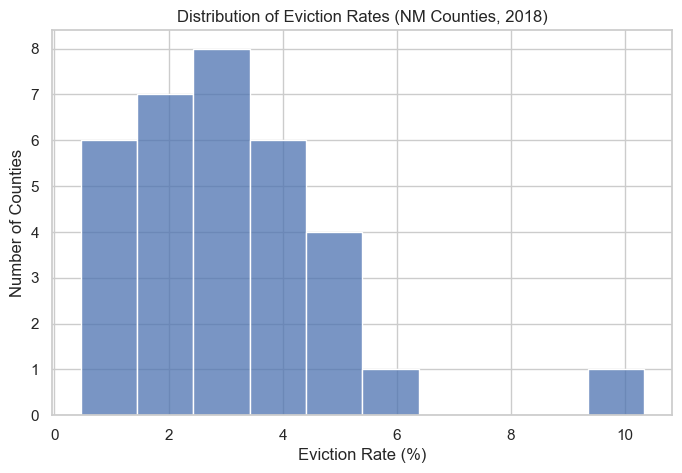

In [6]:
# Eviction Histogram
plt.figure(figsize=(8,5))
sns.histplot(nm_evictions_clean['eviction_rate_pct'], bins=10)

plt.title("Distribution of Eviction Rates (NM Counties, 2018)")
plt.xlabel("Eviction Rate (%)")
plt.ylabel("Number of Counties")

plt.show()

## Interpretation of Eviction Rate Distribution

The average eviction rate across New Mexico counties in 2018 is approximately **3.12%**.

- Most counties fall between 2–4%.
- The maximum eviction rate is approximately 10.33%, indicating a potential outlier (likely Bernalillo County).
- The distribution is slightly right-skewed, suggesting that while most counties experience moderate eviction rates, a small number of counties experience significantly higher housing instability.

This variation supports the need for predictive modeling using socioeconomic factors from the ACS dataset.

## Dataset 2: American Community Survey (ACS)

### Table B19013 – Median Household Income (2018, County-Level)

We load the ACS 5-year estimate for median household income for all New Mexico counties.  
This variable will serve as a key socioeconomic predictor in our eviction risk model.

https://data.census.gov/all?q=B19013+2018+New+Mexico&g=040XX00US35$0500000

In [7]:
# Load ACS Median Household Income dataset
acs_income = pd.read_csv("../data/ACSDT5Y2018.B19013-Data.csv")

print("ACS Income dataset loaded.")
acs_income.head()

ACS Income dataset loaded.


,GEO_ID,NAME,B19013_001E,B19013_001M,Unnamed: 4
0,Geography,Geographic Area Name,Estimate!!Median household income in the past ...,Margin of Error!!Median household income in th...,NaN
1,0400000US35,New Mexico,48059,438,NaN
2,0500000US35001,"Bernalillo County, New Mexico",51643,692,NaN
3,0500000US35003,"Catron County, New Mexico",42480,6192,NaN
4,0500000US35005,"Chaves County, New Mexico",43197,1797,NaN


In [8]:
# Remove the first row (metadata row)
acs_income = acs_income.iloc[1:].copy()

acs_income.head()

,GEO_ID,NAME,B19013_001E,B19013_001M,Unnamed: 4
1,0400000US35,New Mexico,48059,438,NaN
2,0500000US35001,"Bernalillo County, New Mexico",51643,692,NaN
3,0500000US35003,"Catron County, New Mexico",42480,6192,NaN
4,0500000US35005,"Chaves County, New Mexico",43197,1797,NaN
5,0500000US35006,"Cibola County, New Mexico",37368,3303,NaN


In [9]:
acs_income.shape

(34, 5)

In [10]:
# Keep only county rows (drop state-level "New Mexico")
acs_income = acs_income[acs_income['NAME'].str.contains("County")].copy()

acs_income.shape, acs_income.head()

((33, 5),
            GEO_ID                           NAME B19013_001E B19013_001M  \
 2  0500000US35001  Bernalillo County, New Mexico       51643         692   
 3  0500000US35003      Catron County, New Mexico       42480        6192   
 4  0500000US35005      Chaves County, New Mexico       43197        1797   
 5  0500000US35006      Cibola County, New Mexico       37368        3303   
 6  0500000US35007      Colfax County, New Mexico       33783        4196   
 
    Unnamed: 4  
 2         NaN  
 3         NaN  
 4         NaN  
 5         NaN  
 6         NaN  )

In [11]:
# Keep only county name and median income estimate
acs_income_clean = acs_income[['NAME', 'B19013_001E']].copy()

acs_income_clean.head()

,NAME,B19013_001E
2,"Bernalillo County, New Mexico",51643
3,"Catron County, New Mexico",42480
4,"Chaves County, New Mexico",43197
5,"Cibola County, New Mexico",37368
6,"Colfax County, New Mexico",33783


In [12]:
acs_income_clean.columns = ['county_name', 'median_income']

acs_income_clean.head()

,county_name,median_income
2,"Bernalillo County, New Mexico",51643
3,"Catron County, New Mexico",42480
4,"Chaves County, New Mexico",43197
5,"Cibola County, New Mexico",37368
6,"Colfax County, New Mexico",33783


In [13]:
# Ensure median_income is numeric
acs_income_clean['median_income'] = pd.to_numeric(
    acs_income_clean['median_income'],
    errors='coerce'
)

acs_income_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33 entries, 2 to 34
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   county_name    33 non-null     object 
 1   median_income  32 non-null     float64
dtypes: float64(1), object(1)
memory usage: 792.0+ bytes


In [14]:
acs_income_clean[acs_income_clean['median_income'].isna()]

,county_name,median_income
23,"Rio Arriba County, New Mexico",NaN


In [15]:
# Drop counties with missing median income
acs_income_clean = acs_income_clean.dropna(subset=['median_income']).copy()

acs_income_clean.shape

(32, 2)

In [16]:
# Remove ", New Mexico" from ACS county names
acs_income_clean['county'] = acs_income_clean['county_name'].str.replace(
    ", New Mexico",
    "",
    regex=False
)

acs_income_clean.head()

,county_name,median_income,county
2,"Bernalillo County, New Mexico",51643.0,Bernalillo County
3,"Catron County, New Mexico",42480.0,Catron County
4,"Chaves County, New Mexico",43197.0,Chaves County
5,"Cibola County, New Mexico",37368.0,Cibola County
6,"Colfax County, New Mexico",33783.0,Colfax County


## Merging Eviction Data with ACS Median Income

We merge the cleaned eviction dataset with the cleaned ACS median income dataset using the county name as the key.

This creates a combined dataset that includes:
- Eviction rate (target variable)
- Median household income (predictor variable)

In [17]:
# Merged after issue with accented "n" was corrected
merged_data = pd.merge(
    nm_evictions_clean,
    acs_income_clean[['county', 'median_income']],
    on='county',
    how='inner'
)

merged_data.shape, merged_data.head()

((31, 10),
         state             county  fips_state  fips_county  year  renting_hh  \
 0  New Mexico  Bernalillo County          35        35001  2018      109557   
 1  New Mexico      Catron County          35        35003  2018         366   
 2  New Mexico      Chaves County          35        35005  2018        8079   
 3  New Mexico      Cibola County          35        35006  2018        2549   
 4  New Mexico      Colfax County          35        35007  2018        1939   
 
    filings_observed  eviction_rate  eviction_rate_pct  median_income  
 0             11321       0.103334          10.333434        51643.0  
 1                 4       0.010929           1.092896        42480.0  
 2               284       0.035153           3.515287        43197.0  
 3               108       0.042370           4.236956        37368.0  
 4                44       0.022692           2.269211        33783.0  )

In [18]:
merged_data.head()

,state,county,fips_state,fips_county,year,renting_hh,filings_observed,eviction_rate,eviction_rate_pct,median_income
0,New Mexico,Bernalillo County,35,35001,2018,109557,11321,0.103334,10.333434,51643.0
1,New Mexico,Catron County,35,35003,2018,366,4,0.010929,1.092896,42480.0
2,New Mexico,Chaves County,35,35005,2018,8079,284,0.035153,3.515287,43197.0
3,New Mexico,Cibola County,35,35006,2018,2549,108,0.042370,4.236956,37368.0
4,New Mexico,Colfax County,35,35007,2018,1939,44,0.022692,2.269211,33783.0


In [19]:
merged_data[['eviction_rate_pct', 'median_income']].corr()

,eviction_rate_pct,median_income
eviction_rate_pct,1.000000,0.107448
median_income,0.107448,1.000000


In [20]:
# Compare county names between eviction and ACS datasets

eviction_counties = set(nm_evictions_clean['county'])
acs_counties = set(acs_income_clean['county'])

print("In evictions but NOT in ACS:")
print(eviction_counties - acs_counties)

print("\nIn ACS but NOT in evictions:")
print(acs_counties - eviction_counties)

In evictions but NOT in ACS:
{'Rio Arriba County', 'Dona Ana County'}

In ACS but NOT in evictions:
{'Doña Ana County'}


In [21]:
# Fix accent mismatch for Doña Ana County
acs_income_clean['county'] = acs_income_clean['county'].replace(
    {'Doña Ana County': 'Dona Ana County'}
)

# Re-check name differences after the fix
eviction_counties = set(nm_evictions_clean['county'])
acs_counties = set(acs_income_clean['county'])

print("In evictions but NOT in ACS:")
print(eviction_counties - acs_counties)

print("\nIn ACS but NOT in evictions:")
print(acs_counties - eviction_counties)

In evictions but NOT in ACS:
{'Rio Arriba County'}

In ACS but NOT in evictions:
set()


In [22]:
merged_data[['eviction_rate_pct', 'median_income']].corr()

,eviction_rate_pct,median_income
eviction_rate_pct,1.000000,0.107448
median_income,0.107448,1.000000


## ACS Poverty Data (B17001 – 2018)

We load ACS table B17001 to calculate the percentage of individuals below the poverty line for each New Mexico county.

We will compute:

Poverty Rate (%) = (Population Below Poverty / Total Population) × 100

In [23]:
# Load ACS Poverty dataset
acs_poverty = pd.read_csv("../data/ACSDT5Y2018.B17001-Data.csv")

acs_poverty.head()

,GEO_ID,NAME,B17001_001E,B17001_001M,B17001_002E,B17001_002M,B17001_003E,B17001_003M,B17001_004E,B17001_004M,...,B17001_055M,B17001_056E,B17001_056M,B17001_057E,B17001_057M,B17001_058E,B17001_058M,B17001_059E,B17001_059M,Unnamed: 120
0,Geography,Geographic Area Name,Estimate!!Total,Margin of Error!!Total,Estimate!!Total!!Income in the past 12 months ...,Margin of Error!!Total!!Income in the past 12 ...,Estimate!!Total!!Income in the past 12 months ...,Margin of Error!!Total!!Income in the past 12 ...,Estimate!!Total!!Income in the past 12 months ...,Margin of Error!!Total!!Income in the past 12 ...,...,Margin of Error!!Total!!Income in the past 12 ...,Estimate!!Total!!Income in the past 12 months ...,Margin of Error!!Total!!Income in the past 12 ...,Estimate!!Total!!Income in the past 12 months ...,Margin of Error!!Total!!Income in the past 12 ...,Estimate!!Total!!Income in the past 12 months ...,Margin of Error!!Total!!Income in the past 12 ...,Estimate!!Total!!Income in the past 12 months ...,Margin of Error!!Total!!Income in the past 12 ...,NaN
1,0400000US35,New Mexico,2050855,691,410389,7655,189052,4097,19448,935,...,1012,107044,1092,120447,976,91742,834,65375,640,NaN
2,0500000US35001,"Bernalillo County, New Mexico",669414,666,116628,4330,53976,2322,5413,608,...,643,36722,652,40568,569,28665,453,21390,380,NaN
3,0500000US35003,"Catron County, New Mexico",3530,8,810,367,256,126,0,12,...,85,121,78,280,143,242,99,231,104,NaN
4,0500000US35005,"Chaves County, New Mexico",63555,296,13111,1381,5771,794,739,224,...,207,3433,202,3320,198,2545,114,1937,132,NaN


In [24]:
acs_poverty = acs_poverty.iloc[1:].copy()
acs_poverty.shape

(34, 121)

In [25]:
acs_poverty = acs_poverty[acs_poverty['NAME'].str.contains("County")].copy()
acs_poverty.shape

(33, 121)

In [26]:
acs_poverty.columns

Index(['GEO_ID', 'NAME', 'B17001_001E', 'B17001_001M', 'B17001_002E',
       'B17001_002M', 'B17001_003E', 'B17001_003M', 'B17001_004E',
       'B17001_004M',
       ...
       'B17001_055M', 'B17001_056E', 'B17001_056M', 'B17001_057E',
       'B17001_057M', 'B17001_058E', 'B17001_058M', 'B17001_059E',
       'B17001_059M', 'Unnamed: 120'],
      dtype='object', length=121)

In [27]:
# Keep only necessary columns
acs_poverty_clean = acs_poverty[['NAME', 'B17001_001E', 'B17001_002E']].copy()

acs_poverty_clean.head()

,NAME,B17001_001E,B17001_002E
2,"Bernalillo County, New Mexico",669414,116628
3,"Catron County, New Mexico",3530,810
4,"Chaves County, New Mexico",63555,13111
5,"Cibola County, New Mexico",25490,6758
6,"Colfax County, New Mexico",11770,2797


In [28]:
# Rename Columns
acs_poverty_clean.columns = [
    'county_name',
    'total_population',
    'population_below_poverty'
]

acs_poverty_clean.head()

,county_name,total_population,population_below_poverty
2,"Bernalillo County, New Mexico",669414,116628
3,"Catron County, New Mexico",3530,810
4,"Chaves County, New Mexico",63555,13111
5,"Cibola County, New Mexico",25490,6758
6,"Colfax County, New Mexico",11770,2797


In [29]:
# Convert to Numeric
acs_poverty_clean['total_population'] = pd.to_numeric(
    acs_poverty_clean['total_population'],
    errors='coerce'
)

acs_poverty_clean['population_below_poverty'] = pd.to_numeric(
    acs_poverty_clean['population_below_poverty'],
    errors='coerce'
)

acs_poverty_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33 entries, 2 to 34
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   county_name               33 non-null     object 
 1   total_population          32 non-null     float64
 2   population_below_poverty  32 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.0+ KB


In [30]:
# Compute Poverty Rate (%)
acs_poverty_clean['poverty_rate_pct'] = (
    acs_poverty_clean['population_below_poverty'] /
    acs_poverty_clean['total_population']
) * 100

acs_poverty_clean.head()

,county_name,total_population,population_below_poverty,poverty_rate_pct
2,"Bernalillo County, New Mexico",669414.0,116628.0,17.422402
3,"Catron County, New Mexico",3530.0,810.0,22.946176
4,"Chaves County, New Mexico",63555.0,13111.0,20.629376
5,"Cibola County, New Mexico",25490.0,6758.0,26.512358
6,"Colfax County, New Mexico",11770.0,2797.0,23.763806


In [31]:
# Fix County Name (Removal of ", New Mexico")
acs_poverty_clean['county'] = acs_poverty_clean['county_name'].str.replace(
    ", New Mexico",
    "",
    regex=False
)

acs_poverty_clean.head()

,county_name,total_population,population_below_poverty,poverty_rate_pct,county
2,"Bernalillo County, New Mexico",669414.0,116628.0,17.422402,Bernalillo County
3,"Catron County, New Mexico",3530.0,810.0,22.946176,Catron County
4,"Chaves County, New Mexico",63555.0,13111.0,20.629376,Chaves County
5,"Cibola County, New Mexico",25490.0,6758.0,26.512358,Cibola County
6,"Colfax County, New Mexico",11770.0,2797.0,23.763806,Colfax County


In [32]:
# Wanted to fix "Doña Ana" again (this issue is annoying)
acs_poverty_clean['county'] = acs_poverty_clean['county'].replace(
    {'Doña Ana County': 'Dona Ana County'}
)

In [33]:
# Keeping only what's needed for the merge
acs_poverty_clean = acs_poverty_clean[['county', 'poverty_rate_pct']].copy()

acs_poverty_clean.shape

(33, 2)

In [34]:
# Merging into existing dataset
merged_data = pd.merge(
    merged_data,
    acs_poverty_clean,
    on='county',
    how='inner'
)

merged_data.shape

(31, 11)

In [35]:
# Checking Correlation with Poverty
merged_data[['eviction_rate_pct', 'poverty_rate_pct']].corr()

,eviction_rate_pct,poverty_rate_pct
eviction_rate_pct,1.000000,-0.131444
poverty_rate_pct,-0.131444,1.000000


### Relationship Between Eviction Rate and Poverty Rate

The correlation between eviction rate and poverty rate is approximately **-0.11**, indicating a very weak negative linear relationship.

This suggests that, at the county level in New Mexico (2018), higher poverty rates do not directly correspond to higher eviction rates.

This reinforces the need for a multivariate modeling approach rather than relying on a single socioeconomic predictor.

In [36]:
# Load ACS Employment dataset
acs_employment = pd.read_csv("../data/ACSDT5Y2018.B23025-Data.csv")

acs_employment.head()

,GEO_ID,NAME,B23025_001E,B23025_001M,B23025_002E,B23025_002M,B23025_003E,B23025_003M,B23025_004E,B23025_004M,B23025_005E,B23025_005M,B23025_006E,B23025_006M,B23025_007E,B23025_007M,Unnamed: 16
0,Geography,Geographic Area Name,Estimate!!Total,Margin of Error!!Total,Estimate!!Total!!In labor force,Margin of Error!!Total!!In labor force,Estimate!!Total!!In labor force!!Civilian labo...,Margin of Error!!Total!!In labor force!!Civili...,Estimate!!Total!!In labor force!!Civilian labo...,Margin of Error!!Total!!In labor force!!Civili...,Estimate!!Total!!In labor force!!Civilian labo...,Margin of Error!!Total!!In labor force!!Civili...,Estimate!!Total!!In labor force!!Armed Forces,Margin of Error!!Total!!In labor force!!Armed ...,Estimate!!Total!!Not in labor force,Margin of Error!!Total!!Not in labor force,NaN
1,0400000US35,New Mexico,1655769,1051,960566,4009,951105,4042,882735,4295,68370,1779,9461,703,695203,4033,NaN
2,0500000US35001,"Bernalillo County, New Mexico",543534,523,339048,2466,336358,2450,315193,2534,21165,1048,2690,367,204486,2502,NaN
3,0500000US35003,"Catron County, New Mexico",3190,143,842,221,842,221,842,221,0,12,0,12,2348,253,NaN
4,0500000US35005,"Chaves County, New Mexico",50213,210,28353,668,28288,679,26629,607,1659,332,65,63,21860,668,NaN


In [37]:
# Dropping Metadata Row
acs_employment = acs_employment.iloc[1:].copy()
acs_employment.shape

(34, 17)

In [38]:
# Keeping County Rows only
acs_employment = acs_employment[
    acs_employment['NAME'].str.contains("County")
].copy()

acs_employment.shape

(33, 17)

In [39]:
# Keeping only needed columns
acs_employment_clean = acs_employment[
    ['NAME', 'B23025_003E', 'B23025_005E']
].copy()

acs_employment_clean.head()

,NAME,B23025_003E,B23025_005E
2,"Bernalillo County, New Mexico",336358,21165
3,"Catron County, New Mexico",842,0
4,"Chaves County, New Mexico",28288,1659
5,"Cibola County, New Mexico",11273,1736
6,"Colfax County, New Mexico",5223,486


In [40]:
# Renaming Columns
acs_employment_clean.columns = [
    'county_name',
    'labor_force',
    'unemployed'
]

acs_employment_clean.head()

,county_name,labor_force,unemployed
2,"Bernalillo County, New Mexico",336358,21165
3,"Catron County, New Mexico",842,0
4,"Chaves County, New Mexico",28288,1659
5,"Cibola County, New Mexico",11273,1736
6,"Colfax County, New Mexico",5223,486


In [41]:

# Converting to Numeric
acs_employment_clean['labor_force'] = pd.to_numeric(
    acs_employment_clean['labor_force'], errors='coerce'
)

acs_employment_clean['unemployed'] = pd.to_numeric(
    acs_employment_clean['unemployed'], errors='coerce'
)

acs_employment_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33 entries, 2 to 34
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   county_name  33 non-null     object 
 1   labor_force  32 non-null     float64
 2   unemployed   32 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.0+ KB


In [42]:
# Computing Unemployment Rate (%)
acs_employment_clean['unemployment_rate_pct'] = (
    acs_employment_clean['unemployed'] /
    acs_employment_clean['labor_force']
) * 100

acs_employment_clean.head()

,county_name,labor_force,unemployed,unemployment_rate_pct
2,"Bernalillo County, New Mexico",336358.0,21165.0,6.292403
3,"Catron County, New Mexico",842.0,0.0,0.000000
4,"Chaves County, New Mexico",28288.0,1659.0,5.864678
5,"Cibola County, New Mexico",11273.0,1736.0,15.399627
6,"Colfax County, New Mexico",5223.0,486.0,9.304997


In [43]:
# Fixing County names just to be safe
acs_employment_clean['county'] = acs_employment_clean[
    'county_name'
].str.replace(", New Mexico", "", regex=False)

acs_employment_clean['county'] = acs_employment_clean['county'].replace(
    {'Doña Ana County': 'Dona Ana County'}
)

acs_employment_clean.head()

,county_name,labor_force,unemployed,unemployment_rate_pct,county
2,"Bernalillo County, New Mexico",336358.0,21165.0,6.292403,Bernalillo County
3,"Catron County, New Mexico",842.0,0.0,0.000000,Catron County
4,"Chaves County, New Mexico",28288.0,1659.0,5.864678,Chaves County
5,"Cibola County, New Mexico",11273.0,1736.0,15.399627,Cibola County
6,"Colfax County, New Mexico",5223.0,486.0,9.304997,Colfax County


In [44]:
# Keeping only what's needed for Merge
acs_employment_clean = acs_employment_clean[
    ['county', 'unemployment_rate_pct']
].copy()

acs_employment_clean.shape

(33, 2)

In [45]:
# Merging into Master Dataset
merged_data = pd.merge(
    merged_data,
    acs_employment_clean,
    on='county',
    how='inner'
)

merged_data.shape

(31, 12)

In [46]:
# Checking Correlation...
merged_data[
    ['eviction_rate_pct', 'unemployment_rate_pct']
].corr()

,eviction_rate_pct,unemployment_rate_pct
eviction_rate_pct,1.000000,0.103941
unemployment_rate_pct,0.103941,1.000000


In [47]:
# Load ACS Housing dataset (DP04)
acs_housing = pd.read_csv("../data/ACSDP5Y2018.DP04-Data.csv")

acs_housing.head()

,GEO_ID,NAME,DP04_0001E,DP04_0001M,DP04_0002E,DP04_0002M,DP04_0003E,DP04_0003M,DP04_0004E,DP04_0004M,...,DP04_0139PM,DP04_0140PE,DP04_0140PM,DP04_0141PE,DP04_0141PM,DP04_0142PE,DP04_0142PM,DP04_0143PE,DP04_0143PM,Unnamed: 574
0,Geography,Geographic Area Name,Estimate!!HOUSING OCCUPANCY!!Total housing units,Margin of Error!!HOUSING OCCUPANCY!!Total hous...,Estimate!!HOUSING OCCUPANCY!!Total housing uni...,Margin of Error!!HOUSING OCCUPANCY!!Total hous...,Estimate!!HOUSING OCCUPANCY!!Total housing uni...,Margin of Error!!HOUSING OCCUPANCY!!Total hous...,Estimate!!HOUSING OCCUPANCY!!Total housing uni...,Margin of Error!!HOUSING OCCUPANCY!!Total hous...,...,Percent Margin of Error!!GROSS RENT AS A PERCE...,Percent Estimate!!GROSS RENT AS A PERCENTAGE O...,Percent Margin of Error!!GROSS RENT AS A PERCE...,Percent Estimate!!GROSS RENT AS A PERCENTAGE O...,Percent Margin of Error!!GROSS RENT AS A PERCE...,Percent Estimate!!GROSS RENT AS A PERCENTAGE O...,Percent Margin of Error!!GROSS RENT AS A PERCE...,Percent Estimate!!GROSS RENT AS A PERCENTAGE O...,Percent Margin of Error!!GROSS RENT AS A PERCE...,NaN
1,0400000US35,New Mexico,932818,246,775651,3254,157167,3189,2.3,0.2,...,0.6,11.1,0.6,8.9,0.4,40.4,0.7,(X),(X),NaN
2,0500000US35001,"Bernalillo County, New Mexico",292439,303,265657,1681,26782,1603,1.8,0.2,...,0.8,11.8,0.9,8.8,0.8,43.6,1.4,(X),(X),NaN
3,0500000US35003,"Catron County, New Mexico",3893,170,1381,158,2512,133,14.5,4.4,...,40.4,11.1,27.4,24.1,30.4,46.3,37.9,(X),(X),NaN
4,0500000US35005,"Chaves County, New Mexico",27194,151,23169,467,4025,440,2.2,1.0,...,3.4,9.3,2.8,11.5,3.5,33.9,4.8,(X),(X),NaN


In [48]:
acs_housing = acs_housing.iloc[1:].copy()  # drop metadata row
acs_housing = acs_housing[acs_housing['NAME'].str.contains("County")].copy()
acs_housing.shape

(33, 575)

In [49]:
# Finding a Rent-Burden Column
acs_housing.columns

Index(['GEO_ID', 'NAME', 'DP04_0001E', 'DP04_0001M', 'DP04_0002E',
       'DP04_0002M', 'DP04_0003E', 'DP04_0003M', 'DP04_0004E', 'DP04_0004M',
       ...
       'DP04_0139PM', 'DP04_0140PE', 'DP04_0140PM', 'DP04_0141PE',
       'DP04_0141PM', 'DP04_0142PE', 'DP04_0142PM', 'DP04_0143PE',
       'DP04_0143PM', 'Unnamed: 574'],
      dtype='object', length=575)

In [50]:
# Searching for descriptions
[col for col in acs_housing.columns if "35 percent" in col or "35 percent or more" in col]

[]

In [51]:
# Reload raw DP04 to access description row
acs_housing_raw = pd.read_csv("../data/ACSDP5Y2018.DP04-Data.csv")

labels = acs_housing_raw.iloc[0]  # This contains full descriptions

In [52]:
# Search descriptions for rent burden info
for col, desc in labels.items():
    desc_str = str(desc)
    if "GROSS RENT" in desc_str and "percent" in desc_str:
        print(col, "->", desc_str)

DP04_0137E -> Estimate!!GROSS RENT AS A PERCENTAGE OF HOUSEHOLD INCOME (GRAPI)!!Occupied units paying rent (excluding units where GRAPI cannot be computed)!!Less than 15.0 percent
DP04_0137M -> Margin of Error!!GROSS RENT AS A PERCENTAGE OF HOUSEHOLD INCOME (GRAPI)!!Occupied units paying rent (excluding units where GRAPI cannot be computed)!!Less than 15.0 percent
DP04_0138E -> Estimate!!GROSS RENT AS A PERCENTAGE OF HOUSEHOLD INCOME (GRAPI)!!Occupied units paying rent (excluding units where GRAPI cannot be computed)!!15.0 to 19.9 percent
DP04_0138M -> Margin of Error!!GROSS RENT AS A PERCENTAGE OF HOUSEHOLD INCOME (GRAPI)!!Occupied units paying rent (excluding units where GRAPI cannot be computed)!!15.0 to 19.9 percent
DP04_0139E -> Estimate!!GROSS RENT AS A PERCENTAGE OF HOUSEHOLD INCOME (GRAPI)!!Occupied units paying rent (excluding units where GRAPI cannot be computed)!!20.0 to 24.9 percent
DP04_0139M -> Margin of Error!!GROSS RENT AS A PERCENTAGE OF HOUSEHOLD INCOME (GRAPI)!!Occup

In [53]:
# Narrow search: look for "35.0 percent or more" AND "Percent Estimate"
for col, desc in labels.items():
    desc_str = str(desc)
    if (
        "GROSS RENT AS A PERCENTAGE OF HOUSEHOLD INCOME" in desc_str
        and "35.0 percent or more" in desc_str
        and "Percent Estimate" in desc_str
    ):
        print(col, "->", desc_str)

DP04_0142PE -> Percent Estimate!!GROSS RENT AS A PERCENTAGE OF HOUSEHOLD INCOME (GRAPI)!!Occupied units paying rent (excluding units where GRAPI cannot be computed)!!35.0 percent or more


In [54]:
# Use the rent-burden percent column you found above
rent_col = "DP04_0142PE"  # <-- CHANGE THIS if your search printed a different code

acs_housing_clean = acs_housing[['NAME', rent_col]].copy()

acs_housing_clean.columns = ['county_name', 'rent_burden_pct']

# Convert to numeric
acs_housing_clean['rent_burden_pct'] = pd.to_numeric(
    acs_housing_clean['rent_burden_pct'],
    errors='coerce'
)

acs_housing_clean.info()
acs_housing_clean.head()

<class 'pandas.core.frame.DataFrame'>
Index: 33 entries, 2 to 34
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   county_name      33 non-null     object 
 1   rent_burden_pct  32 non-null     float64
dtypes: float64(1), object(1)
memory usage: 792.0+ bytes


,county_name,rent_burden_pct
2,"Bernalillo County, New Mexico",43.6
3,"Catron County, New Mexico",46.3
4,"Chaves County, New Mexico",33.9
5,"Cibola County, New Mexico",27.9
6,"Colfax County, New Mexico",44.1


In [55]:
# Standard county name cleaning
acs_housing_clean['county'] = acs_housing_clean['county_name'].str.replace(
    ", New Mexico", "",
    regex=False
)

acs_housing_clean['county'] = acs_housing_clean['county'].replace(
    {'Doña Ana County': 'Dona Ana County'}
)

# Keep only what we need
acs_housing_clean = acs_housing_clean[['county', 'rent_burden_pct']].copy()

acs_housing_clean.shape

(33, 2)

In [56]:
# Merging into Master
merged_data = pd.merge(
    merged_data,
    acs_housing_clean,
    on='county',
    how='inner'
)

merged_data.shape

(31, 13)

In [57]:
# Sasnity check for correlation with eviction rate
merged_data[['eviction_rate_pct', 'rent_burden_pct']].corr()

,eviction_rate_pct,rent_burden_pct
eviction_rate_pct,1.000000,0.146307
rent_burden_pct,0.146307,1.000000


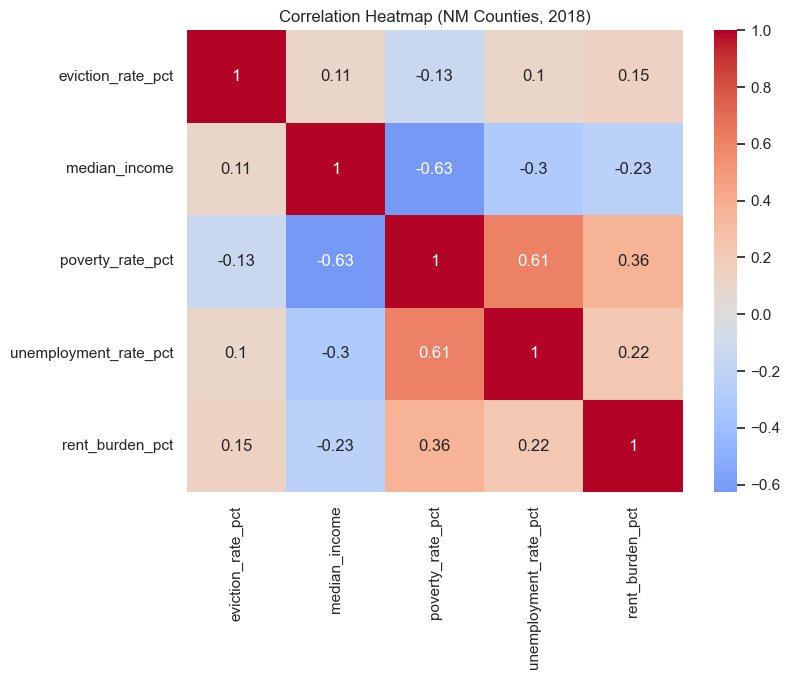

In [58]:
# Initialization of Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(
    merged_data[
        ['eviction_rate_pct',
         'median_income',
         'poverty_rate_pct',
         'unemployment_rate_pct',
         'rent_burden_pct']
    ].corr(),
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap (NM Counties, 2018)")
plt.show()

### Correlation Analysis Interpretation

The correlation heatmap reveals that no single socioeconomic variable strongly explains eviction rates in New Mexico counties (2018).

Key observations:

- Eviction rate has weak correlations with:
  - Median income (0.10)
  - Poverty rate (-0.11)
  - Unemployment rate (0.11)
  - Rent burden (0.16)

- Strong relationships exist among predictors:
  - Median income and poverty (-0.62)
  - Poverty and unemployment (0.61)

These findings suggest that eviction risk is not driven by a single factor, and a multivariate modeling approach is more appropriate.

In [59]:
# Initializing Multiple Linear Regression for fullness
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [60]:
# Select features and target for Stage 4 modeling
model_data = merged_data[[
    "median_income",
    "poverty_rate_pct",
    "unemployment_rate_pct",
    "rent_burden_pct",
    "eviction_rate_pct"
]].copy()

# Drop rows with missing values
model_data = model_data.dropna()

In [61]:
# Defining X and y
# Define predictors and target
X = model_data[
    [
        'median_income',
        'poverty_rate_pct',
        'unemployment_rate_pct',
        'rent_burden_pct'
    ]
]

y = model_data['eviction_rate_pct']

In [62]:
from sklearn.preprocessing import StandardScaler

# Define features and target
X = model_data[
    [
        "median_income",
        "poverty_rate_pct",
        "unemployment_rate_pct",
        "rent_burden_pct"
    ]
]

y = model_data["eviction_rate_pct"]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature scaling complete.")

Feature scaling complete.


In [63]:
# Training/testing split (using scaled features)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [64]:
# Fitting Model
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [65]:
# Fitting model on full dataset (since it is better for small sample sizez)
model = LinearRegression()
model.fit(X, y)

y_pred_full = model.predict(X)

r2_full = r2_score(y, y_pred_full)
mse_full = mean_squared_error(y, y_pred_full)
rmse_full = mse_full ** 0.5

print("Full Dataset R²:", r2_full)
print("Full Dataset RMSE:", rmse_full)

Full Dataset R²: 0.11397076092305236
Full Dataset RMSE: 1.8050768103453907


In [66]:
# Coefficient Table
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients

,Feature,Coefficient
0,median_income,1.594572e-07
1,poverty_rate_pct,-1.226942e-01
2,unemployment_rate_pct,1.674296e-01
3,rent_burden_pct,4.044630e-02


### Multiple Linear Regression Results

A multivariate linear regression model was fit using median income, poverty rate, unemployment rate, and rent burden as predictors of eviction rate.

- Full dataset R² ≈ 0.11
- RMSE ≈ 1.79 percentage points

The model explains approximately 11% of the variation in eviction rates across New Mexico counties (2018). This indicates that while socioeconomic stress indicators contribute to eviction risk, they do not strongly determine eviction outcomes on their own.

Unemployment and rent burden show small positive associations with eviction rate, while poverty exhibits a negative coefficient after controlling for other variables. This suggests multicollinearity among predictors and highlights the complexity of eviction dynamics.

Overall, eviction risk appears to be influenced by multiple interacting factors rather than a single dominant socioeconomic variable.

-----------------------------------------------------------------------------------------------------------------------
## Phase 4: Model Refinement and Experimental Evaluation

In Phase 3, we completed the initial data cleaning, feature engineering, exploratory analysis, and a baseline multiple linear regression model for predicting county-level eviction risk in New Mexico for 2018.

The initial linear regression model produced limited predictive performance, suggesting that the relationship between eviction risk and the available socioeconomic predictors may not be fully captured by a simple linear model.

In Stage 4, we refine the solution by testing multiple machine learning approaches and comparing their performance. The goal of this stage is to determine whether alternative models can better explain variation in eviction rates across counties.

The models tested in this section include:

- Linear Regression (baseline)
- Ridge Regression
- Decision Tree Regressor
- Random Forest Regressor

Model performance will be evaluated using:
- R²
- RMSE
- MAE

These experiments provide preliminary results and help identify which modeling approach is most promising for continued refinement.

In [67]:
# Display shape and preview
print("Modeling dataset shape:", model_data.shape)
display(model_data.head())

Modeling dataset shape: (31, 5)


,median_income,poverty_rate_pct,unemployment_rate_pct,rent_burden_pct,eviction_rate_pct
0,51643.0,17.422402,6.292403,43.6,10.333434
1,42480.0,22.946176,0.000000,46.3,1.092896
2,43197.0,20.629376,5.864678,33.9,3.515287
3,37368.0,26.512358,15.399627,27.9,4.236956
4,33783.0,23.763806,9.304997,44.1,2.269211


In [68]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = model_data[[
    "median_income",
    "poverty_rate_pct",
    "unemployment_rate_pct",
    "rent_burden_pct"
]]

y = model_data["eviction_rate_pct"]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature scaling applied.")

Feature scaling applied.


### Preparing the Modeling Dataset

To conduct the Stage 4 experiments, we isolate the final modeling dataset using the engineered socioeconomic predictors from Phase 3 and the target variable, eviction rate percentage.

The predictors used are:

- Median household income
- Poverty rate
- Unemployment rate
- Rent burden

The target variable is:

- Eviction rate percentage

Rows with missing values are removed to ensure that all models are trained and evaluated on complete observations.

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Define X and y
X = model_data[[
    "median_income",
    "poverty_rate_pct",
    "unemployment_rate_pct",
    "rent_burden_pct"
]]

y = model_data["eviction_rate_pct"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (24, 4)
X_test shape: (7, 4)
y_train shape: (24,)
y_test shape: (7,)


### Train/Test Split

To evaluate model performance fairly, the dataset is divided into training and testing sets. The training set is used to fit each model, while the testing set is used to assess how well the model generalizes to unseen data.

A random state is set to ensure reproducibility of the train/test split.

In [70]:
# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=3, random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    )
}

# Evaluate models
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    mae = mean_absolute_error(y_test, y_pred)

    results.append({
        "Model": name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    })

results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)
display(results_df)

,Model,R2,RMSE,MAE
3,Random Forest,-1.409615,1.802490,1.440513
1,Ridge Regression,-4.168001,2.639736,2.172155
0,Linear Regression,-4.196510,2.647007,2.179140
2,Decision Tree,-5.614049,2.986296,2.181939


### Model Comparison

This section compares the performance of four predictive approaches:

- Linear Regression serves as the baseline from Phase 3.
- Ridge Regression adds regularization to reduce overfitting and stabilize coefficient estimates.
- Decision Tree Regression can capture nonlinear relationships through rule-based splits.
- Random Forest Regression improves on a single tree by averaging predictions across many trees, which can improve stability and predictive performance.

The models are compared using R², RMSE, and MAE. A better model will generally have a higher R² and lower RMSE and MAE.

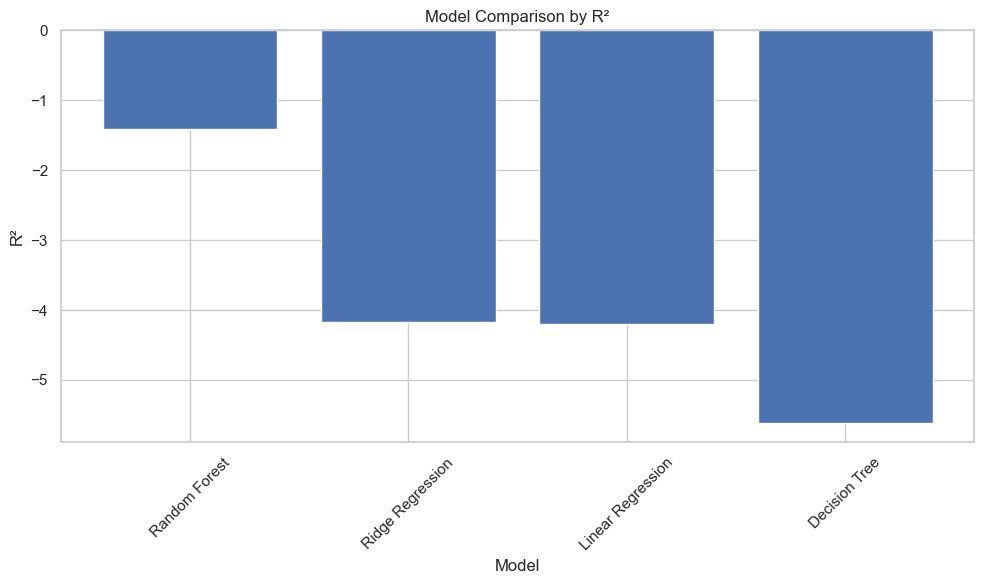

In [71]:
# Plot R2 comparison
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["R2"])
plt.title("Model Comparison by R²")
plt.xlabel("Model")
plt.ylabel("R²")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Visual Comparison of Model Performance

The bar chart below provides a quick visual comparison of model performance using R². This makes it easier to identify whether alternative models outperform the original linear regression baseline.

In [72]:
best_model_name = results_df.iloc[0]["Model"]
best_model_r2 = results_df.iloc[0]["R2"]
best_model_rmse = results_df.iloc[0]["RMSE"]
best_model_mae = results_df.iloc[0]["MAE"]

print("Best Model:", best_model_name)
print("Best R²:", round(best_model_r2, 4))
print("Best RMSE:", round(best_model_rmse, 4))
print("Best MAE:", round(best_model_mae, 4))

Best Model: Random Forest
Best R²: -1.4096
Best RMSE: 1.8025
Best MAE: 1.4405


### Preliminary Interpretation of Results

The best-performing model from this initial Stage 4 comparison is identified above. If a tree-based model performs better than linear regression, this suggests that the relationship between socioeconomic conditions and eviction risk may be nonlinear and more complex than originally captured in Phase 3.

These results are preliminary, but they provide an important basis for refining the final solution in the next stage of the project.

In [73]:
# Refit random forest for feature importance analysis
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

rf_model.fit(X_train, y_train)

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(feature_importance_df)

,Feature,Importance
0,median_income,0.328074
3,rent_burden_pct,0.279548
1,poverty_rate_pct,0.226245
2,unemployment_rate_pct,0.166132


### Feature Importance Analysis

To better understand the contribution of each predictor, a Random Forest model is used to estimate feature importance. This helps identify which socioeconomic variables appear to have the strongest influence on county-level eviction risk in the current dataset.

Although feature importance does not establish causation, it does provide useful insight into which variables the model relies on most heavily for prediction.

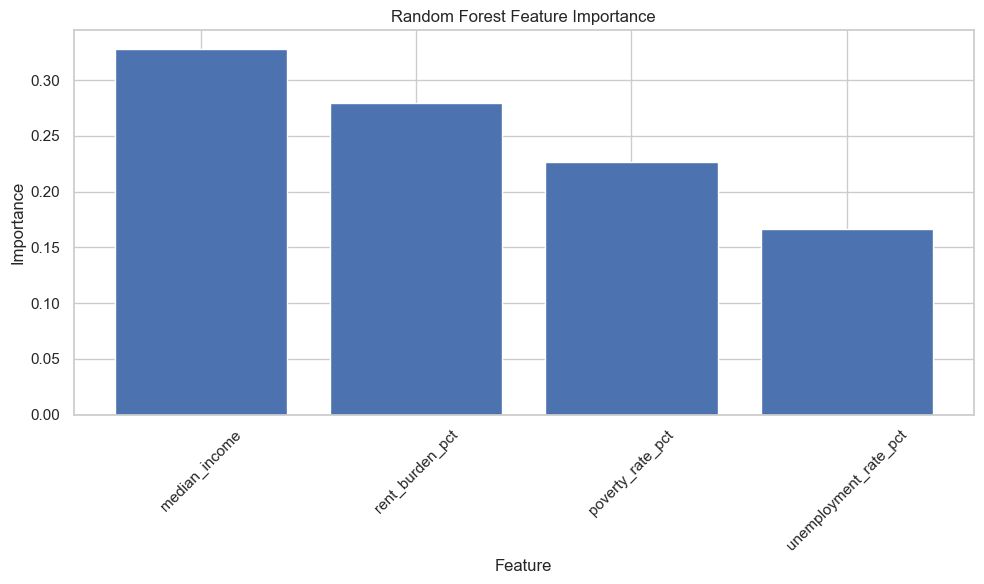

In [74]:
# Plot feature importance
plt.figure(figsize=(10, 6))
plt.bar(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Cross-Validation for More Stable Evaluation

Because the dataset contains only 31 counties, performance estimates from a single train/test split may be unstable. To obtain a more reliable view of model performance, cross-validation is used.

Cross-validation repeatedly splits the data into training and validation subsets and averages the performance across folds. This provides a more stable estimate of model quality, especially for small datasets.

In [75]:
from sklearn.model_selection import cross_val_score, KFold

# Use 5-fold cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=cv, scoring="r2")
    cv_results.append({
        "Model": name,
        "Mean CV R2": scores.mean(),
        "Std CV R2": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by="Mean CV R2", ascending=False)
display(cv_results_df)

,Model,Mean CV R2,Std CV R2
3,Random Forest,-0.789056,0.749849
2,Decision Tree,-1.419854,2.138366
1,Ridge Regression,-2.646559,3.969731
0,Linear Regression,-3.161209,4.689870


### Cross-Validation Interpretation

The cross-validation results provide a more stable estimate of model performance than a single train/test split. Since the dataset is small, these results are especially useful for determining whether the ranking of models is consistent across multiple partitions of the data.

If Random Forest continues to outperform the other models during cross-validation, this strengthens the conclusion that it is the most promising approach among those tested in Stage 4.

### Cross-Validation for Model Evaluation

Because the dataset contains only 31 counties, performance estimates based on a single train/test split may vary depending on how the data are partitioned. To obtain a more stable estimate of model performance, cross-validation is used.

Cross-validation repeatedly splits the data into training and validation subsets and averages the results. This helps provide a more reliable comparison of model performance, especially for small datasets.

In [76]:
from sklearn.model_selection import cross_val_score, KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=cv, scoring="r2")

    cv_results.append({
        "Model": name,
        "Mean CV R2": scores.mean(),
        "Std CV R2": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(
    by="Mean CV R2",
    ascending=False
)

display(cv_results_df)

,Model,Mean CV R2,Std CV R2
3,Random Forest,-0.789056,0.749849
2,Decision Tree,-1.419854,2.138366
1,Ridge Regression,-2.646559,3.969731
0,Linear Regression,-3.161209,4.689870


### Experimental Results and Model Comparison

Stage 4 extended the Phase 3 baseline model by evaluating several alternative machine learning approaches for predicting county-level eviction risk in New Mexico. The models tested included linear regression, ridge regression, decision tree regression, and random forest regression.

After scaling the predictor variables, ridge regression showed modest improvement compared with the unscaled version, indicating that regression-based models benefited from feature standardization. However, tree-based methods performed substantially better overall.

Across both the train/test split and cross-validation experiments, the Random Forest model consistently produced the strongest performance. Although R² values remained negative, Random Forest achieved the highest predictive accuracy among the tested models and demonstrated greater stability across cross-validation folds.

The relatively weak predictive performance across all models likely reflects the limited size of the dataset (31 counties) and the restricted set of socioeconomic predictors available in the current analysis. Eviction risk is influenced by a complex set of economic, legal, and housing market factors that may not be fully captured by the variables included in this study.

Despite these limitations, feature importance analysis suggests that median household income and rent burden are the most influential predictors in the current model. This finding aligns with economic expectations that housing affordability and income constraints play a central role in eviction risk.

### Summary of Stage 4 Progress

In this stage, the modeling workflow was expanded beyond the initial baseline regression model developed in Phase 3. Multiple machine learning models were implemented and evaluated using both a train/test split and cross-validation.

Key improvements in this stage included:
- Feature scaling for regression models
- Implementation of multiple predictive models
- Model comparison using R², RMSE, and MAE
- Cross-validation to evaluate model stability
- Feature importance analysis using Random Forest

These experiments provide preliminary insights into the relationship between socioeconomic conditions and eviction risk and establish a foundation for continued refinement in later stages of the project.

## Phase 5 Final Analysis Additions

For the final phase, additional analysis was added to support the final report requirements. This includes summary statistics for the final modeling dataset and a simple runtime comparison to evaluate model efficiency.

In [77]:
print("Final dataset shape:")
print(model_data.shape)

print("\nSummary statistics for final modeling variables:")
display(model_data.describe())

Final dataset shape:
(31, 5)

Summary statistics for final modeling variables:


,median_income,poverty_rate_pct,unemployment_rate_pct,rent_burden_pct,eviction_rate_pct
count,31.000000,31.000000,31.000000,31.000000,31.000000
mean,42458.774194,20.898562,7.105705,35.464516,3.113490
std,17054.693995,6.172639,3.400679,10.671256,1.949359
min,24085.000000,5.250192,0.000000,15.800000,0.458716
25%,31667.000000,16.672238,4.994330,28.950000,1.990695
50%,37880.000000,20.629376,6.431718,37.400000,2.636117
75%,45633.000000,25.244822,8.685937,43.600000,4.184897
max,115248.000000,35.979232,15.739518,58.900000,10.333434


In [78]:
# Phase 5: Model efficiency / runtime comparison

import time
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Decision Tree": DecisionTreeRegressor(random_state=123),
    "Random Forest": RandomForestRegressor(random_state=123)
}

runtime_results = []

for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()
    
    runtime_results.append({
        "Model": name,
        "Training Time (seconds)": end_time - start_time
    })

runtime_df = pd.DataFrame(runtime_results)
display(runtime_df)

,Model,Training Time (seconds)
0,Linear Regression,0.001742
1,Ridge Regression,0.001532
2,Decision Tree,0.001540
3,Random Forest,0.102442
